<a href="https://colab.research.google.com/github/bhaskar3512/advanced-machine-learning/blob/main/kmedoid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 36.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl size=1959519 sha256=97ed633af06ed268d9e6f356ea48c55f2870e773d42391cb076cf9725ea475cf
  Stored in directory: /root/.cache/pip/wheels/17/4d/c3/c6d5d563c1bf8146d059d63be3678abc2f2801fba0aaf5f0b8
Successfully built scikit-learn-extra


Medoids: [[8 8]
 [2 2]]

Clusters:
Cluster 0 : [array([8, 8]), array([9, 8]), array([8, 9])]
Cluster 1 : [array([1, 2]), array([2, 2]), array([2, 3])]


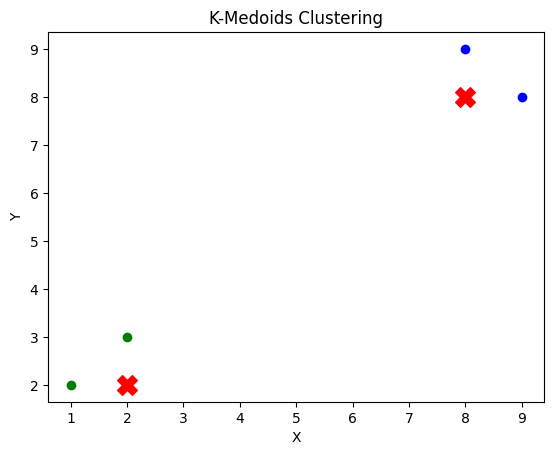

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


def assign_clusters(data, medoids):
    clusters = [[] for _ in range(len(medoids))]
    for point in data:
        dists = [distance(point, m) for m in medoids]
        idx = np.argmin(dists)
        clusters[idx].append(point)
    return clusters


def compute_cost(clusters, medoids):
    cost = 0
    for i in range(len(medoids)):
        for point in clusters[i]:
            cost += distance(point, medoids[i])
    return cost


def k_medoids(data, k, max_iter=100):

    medoids = data[np.random.choice(len(data), k, replace=False)]

    for _ in range(max_iter):

        clusters = assign_clusters(data, medoids)
        current_cost = compute_cost(clusters, medoids)

        best_medoids = medoids.copy()
        best_cost = current_cost

        for i in range(k):
            for point in data:

                if not any((point == medoids).all(axis=1)):

                    new_medoids = medoids.copy()
                    new_medoids[i] = point

                    new_clusters = assign_clusters(data, new_medoids)
                    new_cost = compute_cost(new_clusters, new_medoids)

                    if new_cost < best_cost:
                        best_cost = new_cost
                        best_medoids = new_medoids

        if np.array_equal(best_medoids, medoids):
            break

        medoids = best_medoids

    clusters = assign_clusters(data, medoids)
    return medoids, clusters


data = np.array([
    [1,2],
    [2,2],
    [2,3],
    [8,8],
    [9,8],
    [8,9]
])


medoids, clusters = k_medoids(data, k=2)

print("Medoids:", medoids)
print("\nClusters:")
for i, cluster in enumerate(clusters):
    print("Cluster", i, ":", cluster)


colors = ['blue','green']
for i, cluster in enumerate(clusters):
    cluster = np.array(cluster)
    plt.scatter(cluster[:,0], cluster[:,1], color=colors[i])

plt.scatter(medoids[:,0], medoids[:,1], color='red', marker='X', s=200)

plt.title("K-Medoids Clustering")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()